# Train: Lightweight Model (SMD)

Shared-encoder transformer

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))

from src import load_smd_npz,load_smd, build_model, train

## 1. Load Data

In [2]:
DATA_PATH = load_smd(
    data_dir="../../assets/data/ServerMachineDataset",
    output_path="../../assets/data/smd/smd_processed_data.npz",
    stride = 10
)

Already exists: ../../assets/data/smd/smd_processed_data.npz (delete to re-process)


In [3]:
train_loader, val_loader, test_loader, meta = load_smd_npz(
    DATA_PATH, batch_size=32
)

print(f"Features:   {meta['n_features']}")
print(f"Seq length: {meta['seq_len']}")
print(f"Train:      {meta['n_train']}")
print(f"Val:        {meta['n_val']}")
print(f"Test:       {'yes' if meta['has_test'] else 'no'}")

Features:   38
Seq length: 100
Train:      56460
Val:        14115
Test:       yes


## 2. Build Model

Presets: `pico` (tiny/fast) · `medium` · `ookii` (large)

In [4]:
model = build_model(
    "lightweight",
    input_dim=meta["n_features"],
    preset="medium",
)

n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {n_params:,}")
print(model)

Parameters: 347,726
LightweightTransformerAutoencoder(
  (input_projection): Linear(in_features=38, out_features=96, bias=True)
  (output_projection): Linear(in_features=96, out_features=38, bias=True)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=96, out_features=96, bias=True)
        )
        (linear1): Linear(in_features=96, out_features=384, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=384, out_features=96, bias=True)
        (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (bottle

/home/mouheb/AI-dezem/anomaly-transformer/src/models/model.py:211: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  return nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


## 3. Train

Training on cuda  |  Parameters: 347,726


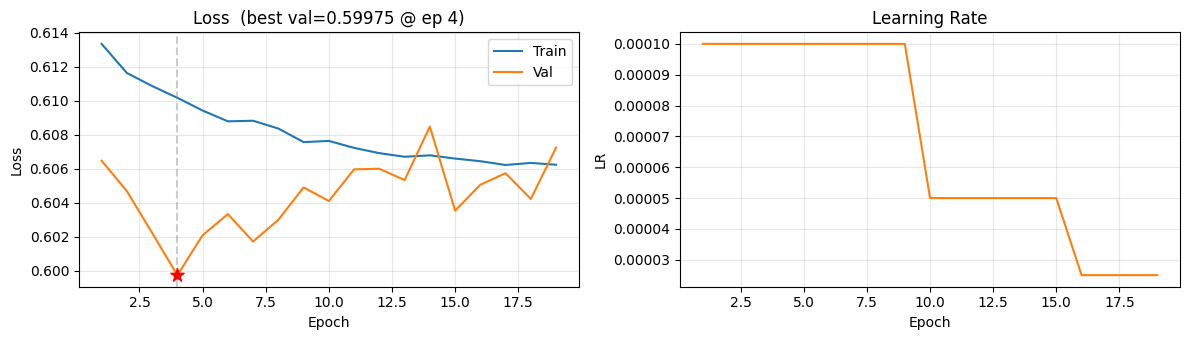

Epochs:   0%|          | 0/40 [00:00<?, ?ep/s]


Early stopping after epoch 20

Done — best val loss: 0.599755


In [8]:
trainer, history = train(
    model,
    train_loader,
    val_loader,
    epochs=40,
    lr=1e-4,
    patience=15,
    checkpoint_dir="../../checkpoints/smd/lightweight",
)

In [14]:
history.display_table(last_n=10)

Epoch,Train Loss,Val Loss,LR,Time
64,0.033278,0.033528,6.25e-05,8.4s
65,0.033091,0.033597,6.25e-05,8.7s
66,0.033040,0.033451,6.25e-05,8.4s
67,0.033028,0.033074,6.25e-05,8.3s
68,0.032994,0.033169,6.25e-05,8.5s
69,0.032946,0.033113,6.25e-05,8.4s
70,0.032928,0.033245,3.13e-05,8.5s
71,0.032834,0.033228,3.13e-05,8.5s
72,0.032791,0.033359,3.13e-05,8.7s
73,0.032773,0.033179,3.13e-05,8.3s


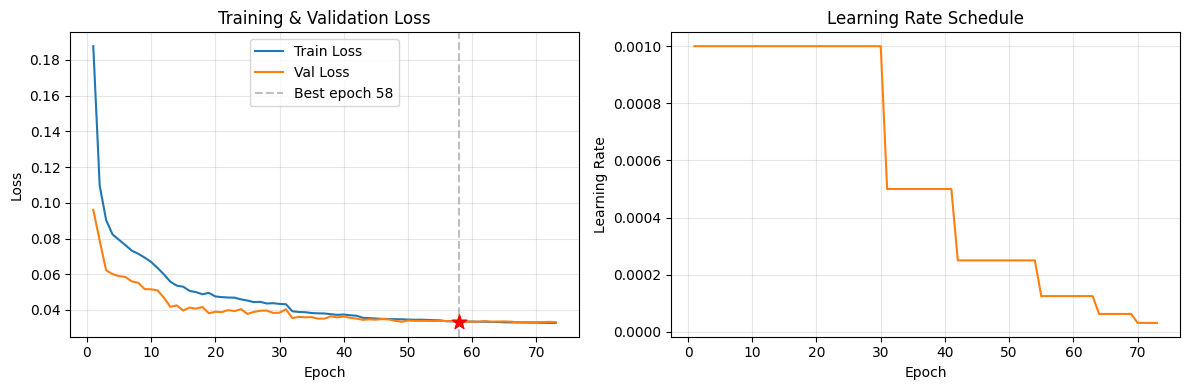

In [15]:
history.plot_learning_curves()

In [16]:
print(f"Best val loss: {trainer.best_val_loss:.6f}")
print(f"Checkpoint:    ../../checkpoints/smd/lightweight/best_model.pt")

Best val loss: 0.033046
Checkpoint:    ../../checkpoints/smd/lightweight/best_model.pt
